# Bayexpress

Using Bayexpress for an alternative approach to differential expression analysis. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
from bayexpress_functions import get_BF_21, get_FC, get_BF_k1

from support_dea import (
    prepare_count_matrix,
    sample_overview_data_wrangling,
    gene_ensemble_id_mapping,
)

In [3]:
METADATA_PATH = f"{os.getcwd()}/../../../hgsoc_data_detective/"
DATA_PATH = f"{os.getcwd()}/../../../alignment_results/"
GTF_PATH = (
    f"{os.getcwd()}/../../../../../Downloads/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
)

In [ ]:
DATA_TYPE = "diss_bulk"  # bulk or diss_bulk

# Load data

- A list of samples and their site of origin
- Gene ensemble id mapping dict to rename the genes

In [32]:
sample_df = sample_overview_data_wrangling(METADATA_PATH, DATA_TYPE)

In [33]:
sample_df.head()

,Site of origin,Long Sample ID
Sample #,,
2018,Omentum,230414/2018
2483,Unknown,230414/2483
2477,Unknown,230414/2477
2460,Omentum,230414/2460
2416,Ovary,230414/2416


In [7]:
gtf = gene_ensemble_id_mapping(GTF_PATH)
dict(gtf[:5])

{'ENSG00000291172': 'SPATA31D5P',
 'ENSG00000129473': 'BCL2L2',
 'ENSG00000273403': 'ENSG00000273403',
 'ENSG00000277369': 'ENSG00000277369',
 'ENSG00000226673': 'LINC01108'}

# Prepare count matrix

In [ ]:
count_matrix = prepare_count_matrix(DATA_PATH)

# Select only bulk / diss bulk samples
if DATA_TYPE == "bulk":
    count_matrix = count_matrix[~count_matrix.index.str.contains("2304")]
elif DATA_TYPE == "diss_bulk":
    count_matrix = count_matrix[count_matrix.index.str.contains("2304")]
else:
    raise ValueError("DATA_TYPE must be either 'bulk' or 'diss_bulk'.")

# Add "site of origin" from sample_df
count_matrix.index.name = "Long Sample ID"
count_df = pd.merge(
    sample_df,
    count_matrix,
    how="inner",
    left_on="Long Sample ID",
    right_on="Long Sample ID",
)
count_df = count_df.set_index("Long Sample ID")

In [ ]:
# Only consider ovary and omentum samples
count_df = count_df[
    (count_df["Site of origin"] == "Omentum") | (count_df["Site of origin"] == "Ovary")
]

# Only consider genes that have more than 10 read counts in total
count_df = count_df[pd.Index(["Site of origin"]).append(count_df.columns[1:][count_df.iloc[:, 1:].sum(axis=0) >= 10])]
# Rename gene IDs to gene names
count_df.rename(columns=dict(gtf), inplace=True)

In [36]:
count_df.head()

,Site of origin,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,ENSG00000291296,ENSG00000291297,ENSG00000291299,PRSS30P,LY6S,TMEM276,ENSG00000291342,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,Omentum,485,1,1400,86,78,845,2036,843,376,...,3,5,426,15,9,47,4,0,1,2
230414/2460,Omentum,499,3,836,88,77,417,3003,548,338,...,4,2,177,117,5,204,1,0,0,0
230414/2416,Ovary,466,11,402,122,79,465,384,359,188,...,10,6,151,7,0,38,0,0,6,12
230414/2278,Omentum,557,3,3726,340,209,712,2999,912,480,...,7,2,833,158,43,678,8,1,1,0
230414/2249,Ovary,430,4,1119,311,216,541,3651,1355,308,...,3,0,334,18,5,97,1,0,0,0


In [ ]:
# Split the count_df into omentum and ovary dataframes
omentum_df = count_df[count_df["Site of origin"]=="Omentum"].drop(columns=["Site of origin"]).T
ovary_df = count_df[count_df["Site of origin"]=="Ovary"].drop(columns=["Site of origin"]).T

In [39]:
ovary_df

Long Sample ID,230414/2416,230414/2249,230414/2129,230414/2526,230418/2423
TSPAN6,466,430,551,515,192
TNMD,11,4,1,0,0
DPM1,402,1119,707,794,605
SCYL3,122,311,134,136,197
C1orf112,79,216,114,73,133
...,...,...,...,...,...
TMEM276,38,97,144,13,26
ENSG00000291342,0,1,1,0,0
ENSG00000292246,0,0,2,0,1
ENSG00000292271,6,0,0,0,1


# Calculate Bayes Factor and Log Fold Change

In [40]:
# sum of all reads per gene
n_omentum = omentum_df.sum(axis=1)
n_ovary = ovary_df.sum(axis=1)

In [41]:
# sum of all reads
N_omentum = n_omentum.sum()
N_ovary = n_ovary.sum()

In [ ]:
# Using the Bayexpress package to calculate the Bayes factors and fold changes

# Bayexpress notation:
# BF_21 compares the two groups (ovary vs omentum)
# FC is the Log2FoldChange
# BF_k1_omentum compares samples in the group omentum
# BF_k1_ovary compares samples in the group ovary
df = pd.DataFrame(
    {
        "BF_21": get_BF_21(N_omentum, n_omentum, N_ovary, n_ovary),
        "FC": get_FC(N_omentum, n_omentum, N_ovary, n_ovary),
        "BF_k1_omentum": get_BF_k1(omentum_df),
        "BF_k1_ovary": get_BF_k1(ovary_df),
    }
)

# Result interpretation

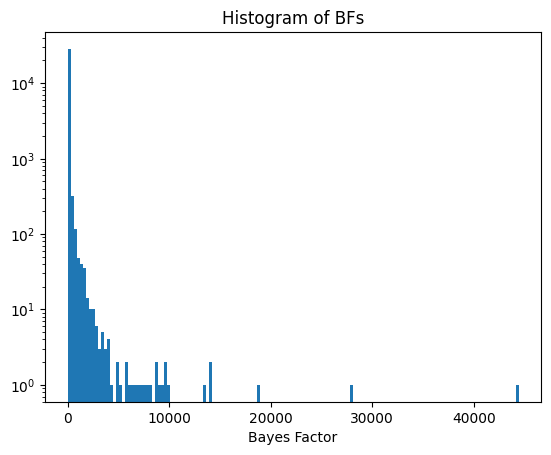

In [ ]:
# Plot histogram of Bayes Factors (BFs)
fig, ax = plt.subplots()
ax.hist(df["BF_21"], bins=150)
ax.set_yscale("log")
ax.set_xlabel("Bayes Factor")
ax.set_title("Histogram of BFs")

plt.show()

In [46]:
df.sort_values(by="BF_21", ascending=False)

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
MT-CO1,44411.797267,0.557921,110671.886380,73468.349807
CLU,27915.351482,-1.693482,128980.027818,4897.881006
MT-CO3,18823.001029,0.506003,51286.160313,66055.560156
PLEC,14180.075060,-1.448952,35110.669531,1909.879412
COL1A1,14145.931641,-0.696253,100644.212862,20476.317209
...,...,...,...,...
ENSG00000275228,-7.150150,0.371385,-59.866826,-25.932776
KRT74,-7.150150,0.371385,-59.593335,-26.161268
ABCC5-AS1,-7.150150,0.371385,-61.009165,-25.394387
ENSG00000289962,-7.150150,0.371385,-58.613289,-25.830678


In [47]:
# BF < 0: no change in gene expression
len(df[df["BF_21"]<0])

19558

In [48]:
# BF > 0: change in gene expression
len(df[df["BF_21"]>0])

9417

In [ ]:
# In the Bayexpress paper, they choose BF > 1 as a cut-off
df[df["BF_21"]>1].sort_values("BF_21", ascending=False)

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
MT-CO1,44411.797267,0.557921,110671.886380,73468.349807
CLU,27915.351482,-1.693482,128980.027818,4897.881006
MT-CO3,18823.001029,0.506003,51286.160313,66055.560156
PLEC,14180.075060,-1.448952,35110.669531,1909.879412
COL1A1,14145.931641,-0.696253,100644.212862,20476.317209
...,...,...,...,...
FAAP24,1.007795,0.753258,-38.936927,-4.305075
GXYLT2,1.006015,-0.260211,42.099495,135.482329
XRCC6,1.004810,-0.090887,300.987292,27.713809
ZWILCH,1.003838,0.375288,-31.522254,-15.794619


In [50]:
# Let's compare it to our pydeseq2 analysis
# Using the same LogFoldChange cut-off and using BF to assess significantly DE genes
df[(abs(df["FC"])>0.5)&(df["BF_21"]>1)].sort_values("BF_21", ascending=False).head(10)

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
MT-CO1,44411.797267,0.557921,110671.886380,73468.349807
CLU,27915.351482,-1.693482,128980.027818,4897.881006
MT-CO3,18823.001029,0.506003,51286.160313,66055.560156
PLEC,14180.075060,-1.448952,35110.669531,1909.879412
COL1A1,14145.931641,-0.696253,100644.212862,20476.317209
AHNAK,9527.220972,-0.942607,21251.361122,2990.640578
MUC16,9504.061517,-1.443463,42625.462842,7927.371880
IGF2,9252.946024,-4.366387,16153.628540,62.112576
HSPA5,8972.798996,-1.132601,39684.826279,1993.243846
ZFP36L1,8836.205420,-1.004460,32976.272357,1069.518624


## Dissociated bulk

Note I reran the above analysis with the appropriate DATA_TYPE for the Dissociated bulk and Bulk sections.

In [117]:
# Let's compare the top 10 genes in each approach

# For dissociated bulk, pydeseq2 only yielded 9 DE genes
comp_diss_bulk_genes = [
    "CILP",
    "IGF2",
    "MEFV",
    "C9orf72",
    "P2RY14",
    "GLIS3-AS1",
    "LINC02940",
    "IGF2-AS",
    "ENSG00000289074",
]

In [ ]:
# These are considered significantly DE according to Bayexpress too, but some of them don't stand out as much.
df.loc[comp_diss_bulk_genes]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
CILP,1678.646770,-3.123576,2043.687443,13.992071
IGF2,9252.946024,-4.366387,16153.628540,62.112576
MEFV,300.809008,3.342019,-40.800076,369.220538
C9orf72,550.100088,1.508125,12.199485,405.937905
P2RY14,47.295961,2.206052,-43.955159,-15.512673
GLIS3-AS1,106.917537,5.106456,-58.416429,122.035349
LINC02940,60.002062,1.649343,-42.264754,4.598968
IGF2-AS,43.598582,-4.989684,47.710985,-26.128375
ENSG00000289074,15.953269,-1.730638,-41.873957,-21.878104


Which genes are in the top 10 for both approaches?
Only IGF2.

In fact, even in the top 50, only IGF2 is seen both lists.
So, there is very little overlap between the two approaches.

## Bulk

In [ ]:
comp_bulk_genes = list(pd.read_csv("../results/de_genes_bulk_rrna-.csv", index_col=0).index)
len(comp_bulk_genes)

In [241]:
# All DE genes from pydeseq2 are identified by both methods
len(set(df.index)&set(comp_bulk_genes))

148

In [253]:
# Let's compare the top 10
# Only STAR overlaps
# Top 50: STAR and PEG3 overlap
set(comp_bulk_genes[:50])&set(df.sort_values(by="BF_21", ascending=False).index[:50])

{'PEG3', 'STAR'}

## Adipocyte markers

Having a look at some markers that Ariel considered, but nothing is significantly DE.

In [159]:
df[df.index.str.contains("ADIPOQ")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
ADIPOQ,-4.309094,-1.244006,-37.188196,-22.562625


In [160]:
df[df.index.str.contains("PLIN1")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
PLIN1,-6.221083,-0.188621,-32.09508,-21.040212


In [161]:
df[df.index.str.contains("CIDEC")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
CIDEC,-4.156385,-2.292369,-64.162718,-26.087115


Some open questions / thoughts:

I am not sure how the total number of samples (ovary + omentum) is affecting this analysis.

I am also not sure how the asymmetry in the number of samples (ovary 5-7, omentum 10) is affecting the analysis.

# Plots
## Q plots

They are used extensively in the Bayexpress paper, but I think we do not have enough samples for these plots to be valuable.

In [123]:
omentum_q = pd.DataFrame()

for col in omentum_df.columns:
    omentum_q[col] = (omentum_df[col] + 1) / (sum(omentum_df[col])+2)

In [124]:
ovary_q = pd.DataFrame()

for col in ovary_df.columns:
    ovary_q[col] = (ovary_df[col] + 1) / (sum(ovary_df[col])+2)

In [125]:
def q_plot(exp_1, exp_2):

    # printing q-plots
    for t in range(len(exp_1)):
        fig, ax = plt.subplots(figsize=(8, 6))

        # histogram Exp 1
        ax.hist(exp_1.iloc[t], 10, density=False, histtype='step', color='#332288',
                alpha=0.4, orientation='horizontal')

        # histogram Exp 2
        ax.hist(exp_2.iloc[t], 10, density=False, histtype='step', color='#DDCC77',
                alpha=0.4, orientation='horizontal')


        # scatter Exp 1
        ax.scatter(np.arange(1,len(exp_1.columns)+1), exp_1.iloc[t],
                
            c='#332288', s=30, 
            label='Omentum',
            alpha=0.9, edgecolors='none')
        
        # scatter Exp 2
        ax.scatter(np.arange(1,len(exp_2.columns)+1), exp_2.iloc[t],
                
            c='#DDCC77', s=30, 
            label='Ovary',
            alpha=0.9, edgecolors='none')
        
        ax.legend(loc='upper right')

        # Use tex in labels
        ax.set_xticks(np.arange(1,len(exp_1.columns)+1))
        ax.set_xticklabels('')

        # formatting y axis ticks
        plt.gca().ticklabel_format(axis='y', style='plain', useOffset=False)

        ax.set_xlabel('Replicates')
        ax.set_ylabel('q = (n+1) / (N+2)')
        ax.set_title(f"{exp_1.iloc[t].name}")

        plt.show()

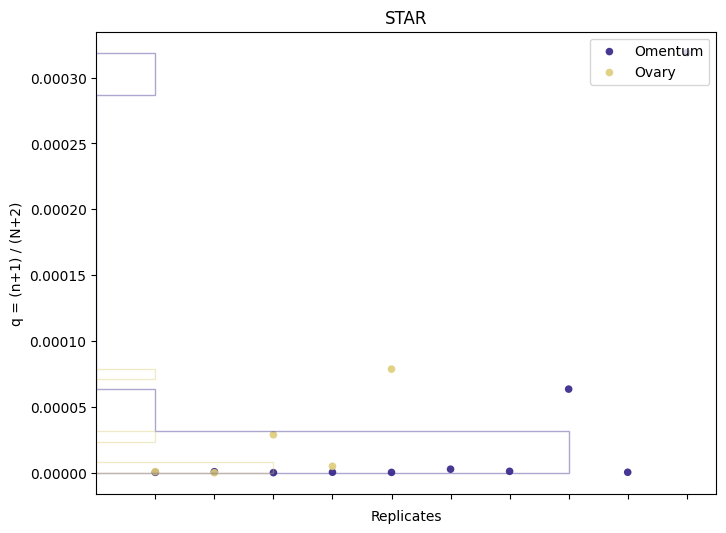

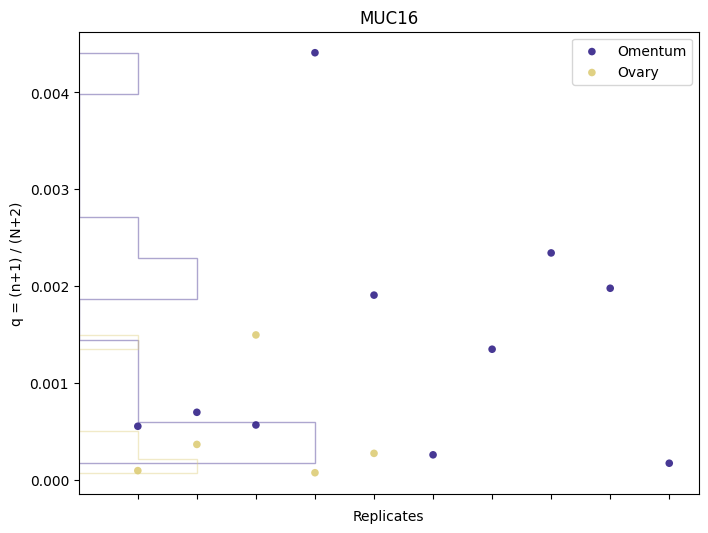

In [126]:
# I am not loving these plots.
# They'd probably be more helpful if we had more samples.
genes = ["STAR", "MUC16"]
q_plot(omentum_q.loc[genes], ovary_q.loc[genes])

## "Volcano" plot

The traditional volcano plot for RNA-seq analysis plots the log-fold change (x-axis) against the adjusted p-value, such that genes that end up in the upper left and right corners are of interest.

For the Bayexpress analysis, instead of the adjusted p-value, we are using the Bayes factor. The interpretation of the plot is very similar to the traditional volcano plot.

In [ ]:
# Loading the adipocyte markers from the Emont et al. paper
# See README for more information
adipocyte_markers_df = pd.read_excel("../data/emont2022s1.xlsx", sheet_name="adipocyte markers", header=1).set_index("Unnamed: 0")
adipocyte_markers_df.index.name = None

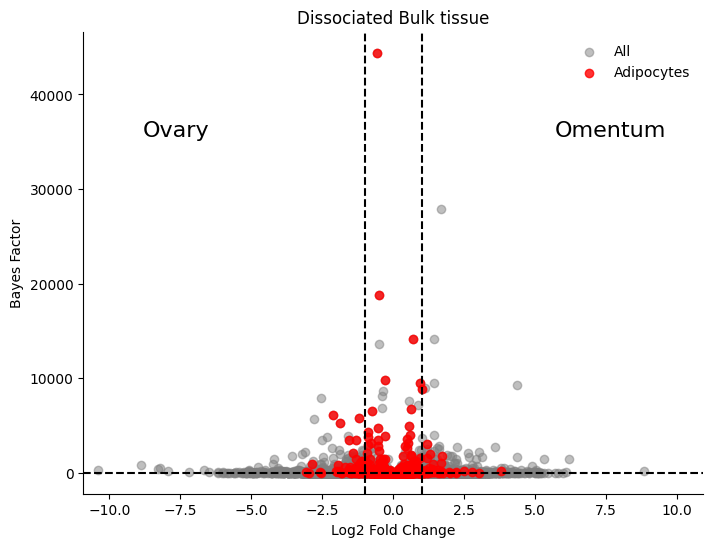

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    -df["FC"], 
    df["BF_21"],
    c="grey",
    label="All",
    alpha=0.5
)

# # Plot adipocyte genes
plt.scatter(
    -df[df.index.isin(list(adipocyte_markers_df.index))]["FC"],
    df[df.index.isin(list(adipocyte_markers_df.index))]["BF_21"],
    c='red', 
    label='Adipocytes', 
    alpha=0.8
)

x_lim = abs(df["FC"]).max()*1.05
plt.xlim([-x_lim, x_lim])
y_lim = df["BF_21"].max()

# # Add vertical lines for fold change threshold (optional)
plt.axvline(x=-1, color='black', linestyle='--')
plt.axvline(x=1, color='black', linestyle='--')

# # Add horizontal line for significance threshold
plt.axhline(y=1, color='black', linestyle='--')

plt.xlabel('Log2 Fold Change')
plt.ylabel('Bayes Factor')
plt.title(f"{DATA_TYPE} tissue")

plt.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.text(-x_lim*0.7, y_lim*0.8, "Ovary", size=16, ha="center")
plt.text(x_lim*0.7, y_lim*0.8, "Omentum", size=16, ha="center")

plt.show()

In [52]:
filename = f"../results/figures/volcano_plot_bayexpress_{DATA_TYPE}"
fig.savefig(filename + ".png", bbox_inches="tight")
fig.savefig(filename + ".pdf", bbox_inches="tight")